# CReST: Contextual Robustness and Subgroup Analysis

Evaluates hidden-target representation robustness across contextual subgroups using frozen out-of-fold representations. These analyses assess robustness rather than causal fairness.

In [ ]:
import warnings
warnings.filterwarnings('ignore')

In [ ]:
# CReST educational interpretation environment

from pathlib import Path
import json
import pickle
import sys
import gc

import numpy as np
import pandas as pd

import torch
from torch.utils.data import Dataset, DataLoader

from scipy.stats import spearmanr

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.metrics import (
    r2_score,
    mean_absolute_error
)


BASE_DIR = Path.cwd()

HANDOFF_DIR = (
    BASE_DIR
    / "processed"
    / "crest_v5_handoff"
)

FINAL_RESOURCE_ROOT = (
    BASE_DIR
    / "processed"
    / "crest_final_7fold"
)

FINAL_TEST_ROOT = (
    BASE_DIR
    / "processed"
    / "crest_final_test_sets"
)

CHECKPOINT_ROOT = (
    BASE_DIR
    / "checkpoints"
    / "final_7fold"
)

RESULTS_DIR = (
    BASE_DIR
    / "results"
)

FIG_DIR = (
    BASE_DIR
    / "figures"
)


RESULTS_DIR.mkdir(
    exist_ok=True
)

FIG_DIR.mkdir(
    exist_ok=True
)


if str(BASE_DIR) not in sys.path:

    sys.path.insert(
        0,
        str(BASE_DIR)
    )


import crest_final_core as crest_core


# Configuration

with open(
    HANDOFF_DIR
    / "handoff_config.json",
    "r",
    encoding="utf-8"
) as f:

    CONFIG = json.load(f)


with open(
    RESULTS_DIR
    / "crest_final_training_protocol.json",
    "r",
    encoding="utf-8"
) as f:

    FINAL_TRAINING_PROTOCOL = json.load(f)


GLOBAL_SEED = int(
    CONFIG[
        "global_seed"
    ]
)


device = torch.device(
    "cuda"
    if torch.cuda.is_available()
    else "cpu"
)


# Core handoff

primary_meta = pd.read_pickle(
    HANDOFF_DIR
    / "primary_meta.pkl"
)

model_context = pd.read_pickle(
    HANDOFF_DIR
    / "model_context.pkl"
)


credit_tokens = np.load(
    HANDOFF_DIR
    / "credit_tokens.npy",
    mmap_mode="r"
)

behaviour_tokens = np.load(
    HANDOFF_DIR
    / "behaviour_tokens.npy",
    mmap_mode="r"
)

performance_mask = np.load(
    HANDOFF_DIR
    / "performance_mask.npy",
    mmap_mode="r"
)

interaction_mask = np.load(
    HANDOFF_DIR
    / "interaction_mask.npy",
    mmap_mode="r"
)

student_design_mask = np.load(
    HANDOFF_DIR
    / "student_design_mask.npy",
    mmap_mode="r"
)

process_tensor = np.load(
    HANDOFF_DIR
    / "process_tensor.npy",
    mmap_mode="r"
)

booklet_nuisance_ids = np.load(
    HANDOFF_DIR
    / "booklet_nuisance_ids.npy",
    mmap_mode="r"
)

item_domain_ids = np.load(
    HANDOFF_DIR
    / "item_domain_ids.npy",
    mmap_mode="r"
)

item_ideation_ids = np.load(
    HANDOFF_DIR
    / "item_ideation_ids.npy",
    mmap_mode="r"
)


BOOKLET_TO_SIGNATURE = np.load(
    BASE_DIR
    / "processed"
    / "crest_design_calibration"
    / "booklet_to_signature.npy"
)


# Same locked split as Notebook 06
ITEM_SET_A = np.array(
    [
        0, 1, 5, 6, 7, 8, 9, 10,
        12, 15, 17, 20, 24, 27, 28, 31
    ],
    dtype=np.int64
)

ITEM_SET_B = np.array(
    [
        2, 3, 4, 11, 13, 14, 16, 18,
        19, 21, 22, 23, 25, 26, 29, 30
    ],
    dtype=np.int64
)


direction_specs = {

    "A_to_B": (
        ITEM_SET_A,
        ITEM_SET_B
    ),

    "B_to_A": (
        ITEM_SET_B,
        ITEM_SET_A
    )
}


print(
    "Students:",
    len(primary_meta)
)

print(
    "Education systems:",
    primary_meta[
        "CNT"
    ].nunique()
)

print(
    "Device:",
    device
)

print(
    "Final model architecture remains locked."
)

Students: 142564
Education systems: 63
Device: cpu
Final model architecture remains locked.


In [ ]:
# Fold-specific resource and split helpers

class PreprocessorUnpickler(
    pickle.Unpickler
):

    def find_class(
        self,
        module,
        name
    ):

        if (
            module == "__main__"
            and
            name in {
                "ContextPreprocessor",
                "ProcessPreprocessor"
            }
        ):

            return getattr(
                crest_core,
                name
            )


        return super().find_class(
            module,
            name
        )


def load_fold_resources(
    outer_fold
):

    fold_dir = (
        FINAL_RESOURCE_ROOT
        / f"fold_{outer_fold}"
    )


    with open(
        fold_dir
        / "preprocessors.pkl",
        "rb"
    ) as f:

        pp = (
            PreprocessorUnpickler(
                f
            ).load()
        )


    return {

        "student_pp":
            pp["student_pp"],

        "school_pp":
            pp["school_pp"],

        "process_pp":
            pp["process_pp"],

        "country_to_train_id":
            pp["country_to_train_id"],

        "credit_item_mean":
            np.load(
                fold_dir
                / "credit_item_mean.npy"
            ),

        "behaviour_item_rates":
            np.load(
                fold_dir
                / "behaviour_item_rates.npy"
            ),

        "process_item_mean":
            np.load(
                fold_dir
                / "process_item_mean.npy"
            ),

        "process_item_std":
            np.load(
                fold_dir
                / "process_item_std.npy"
            ),

        "signature_profiles":
            np.load(
                fold_dir
                / "signature_profiles.npy"
            ),

        "signature_token_profiles":
            np.load(
                fold_dir
                / "signature_token_profiles.npy"
            )
    }


def make_eval_split_data(
    indices,
    resources
):

    student_ctx = (
        resources[
            "student_pp"
        ].transform(
            model_context.iloc[
                indices
            ]
        )
    )


    school_ctx = (
        resources[
            "school_pp"
        ].transform(
            model_context.iloc[
                indices
            ]
        )
    )


    process_raw = np.asarray(
        process_tensor[
            indices
        ],
        dtype=np.float32
    )


    (
        process_values,
        process_obs_mask
    ) = (
        resources[
            "process_pp"
        ].transform(
            process_raw
        )
    )


    countries = (
        primary_meta.iloc[
            indices
        ][
            "CNT"
        ]
        .to_numpy()
    )


    country_ids = np.asarray(
        [
            resources[
                "country_to_train_id"
            ].get(
                country,
                -1
            )

            for country in countries
        ],
        dtype=np.int64
    )


    booklet_ids = np.asarray(
        booklet_nuisance_ids[
            indices
        ],
        dtype=np.int64
    )


    signature_ids = (
        BOOKLET_TO_SIGNATURE[
            booklet_ids
        ]
        .astype(
            np.int64
        )
    )


    return {

        "credit_tokens":
            np.asarray(
                credit_tokens[
                    indices
                ],
                dtype=np.int64
            ),

        "behaviour_tokens":
            np.asarray(
                behaviour_tokens[
                    indices
                ],
                dtype=np.int64
            ),

        "performance_mask":
            np.asarray(
                performance_mask[
                    indices
                ],
                dtype=bool
            ),

        "interaction_mask":
            np.asarray(
                interaction_mask[
                    indices
                ],
                dtype=bool
            ),

        "design_mask":
            np.asarray(
                student_design_mask[
                    indices
                ],
                dtype=bool
            ),

        "process_raw":
            process_raw,

        "process_values":
            process_values,

        "process_mask":
            process_obs_mask,

        "student_continuous":
            student_ctx[
                "continuous"
            ],

        "student_continuous_mask":
            student_ctx[
                "continuous_mask"
            ],

        "student_categorical":
            student_ctx[
                "categorical"
            ],

        "school_continuous":
            school_ctx[
                "continuous"
            ],

        "school_continuous_mask":
            school_ctx[
                "continuous_mask"
            ],

        "school_categorical":
            school_ctx[
                "categorical"
            ],

        "booklet_nuisance_id":
            booklet_ids,

        "design_signature_id":
            signature_ids,

        "country_train_id":
            country_ids,

        "CNT":
            countries,

        "CNTSTUID":
            primary_meta.iloc[
                indices
            ][
                "CNTSTUID"
            ].to_numpy()
    }


def restore_final_model(
    outer_fold,
    resources
):

    model = crest_core.CReSTFinal(

        resources=resources,

        item_domain_ids=(
            item_domain_ids
        ),

        item_ideation_ids=(
            item_ideation_ids
        ),

        n_train_countries=45,
        n_booklets=30,
        n_design_signatures=10,

        n_domains=4,
        n_processes=3,

        d_model=int(
            CONFIG[
                "d_model"
            ]
        ),

        latent_dim=int(
            CONFIG[
                "latent_dim"
            ]
        ),

        n_heads=int(
            CONFIG[
                "n_heads"
            ]
        ),

        n_layers=int(
            CONFIG[
                "n_layers"
            ]
        ),

        dropout=float(
            CONFIG[
                "dropout"
            ]
        )
    ).to(device)


    checkpoint = torch.load(

        CHECKPOINT_ROOT
        / f"fold_{outer_fold}"
        / "crest_final_best.pt",

        map_location=device
    )


    model.load_state_dict(
        checkpoint[
            "model_state_dict"
        ]
    )

    model.eval()


    return model


print(
    "Fold helpers ready."
)

Fold helpers ready.


In [ ]:
# Disjoint-item helper functions

def hide_target_items(
    split_data,
    hidden_items
):

    d = split_data.copy()


    for key in [
        "credit_tokens",
        "behaviour_tokens",
        "performance_mask",
        "interaction_mask",
        "design_mask",
        "process_raw",
        "process_values",
        "process_mask"
    ]:

        d[key] = (
            split_data[
                key
            ].copy()
        )


    d[
        "credit_tokens"
    ][
        :,
        hidden_items
    ] = 0


    d[
        "behaviour_tokens"
    ][
        :,
        hidden_items
    ] = 0


    d[
        "performance_mask"
    ][
        :,
        hidden_items
    ] = False


    d[
        "interaction_mask"
    ][
        :,
        hidden_items
    ] = False


    d[
        "design_mask"
    ][
        :,
        hidden_items
    ] = False


    d[
        "process_raw"
    ][
        :,
        hidden_items,
        :
    ] = 0.0


    d[
        "process_values"
    ][
        :,
        hidden_items,
        :
    ] = 0.0


    d[
        "process_mask"
    ][
        :,
        hidden_items,
        :
    ] = False


    return d


def observed_credit_target(
    split_data,
    target_items
):

    tokens = (
        split_data[
            "credit_tokens"
        ][
            :,
            target_items
        ]
    )


    mask = (
        split_data[
            "performance_mask"
        ][
            :,
            target_items
        ]
        &
        (tokens >= 1)
        &
        (tokens <= 3)
    )


    score = (
        tokens.astype(
            np.float32
        )
        -
        1.0
    ) / 2.0


    score = np.where(
        mask,
        score,
        0.0
    )


    count = mask.sum(
        axis=1
    )


    mean_score = np.divide(

        score.sum(
            axis=1
        ),

        count,

        out=np.full(
            len(score),
            np.nan,
            dtype=np.float32
        ),

        where=(
            count > 0
        )
    )


    return (
        mean_score,
        count
    )


def make_signal_probe():

    return Pipeline(
        [
            (
                "scale",
                StandardScaler()
            ),

            (
                "ridge",
                Ridge(
                    alpha=1.0
                )
            )
        ]
    )


def regression_metrics(
    y_true,
    y_pred
):

    return {

        "r2":
            float(
                r2_score(
                    y_true,
                    y_pred
                )
            ),

        "mae":
            float(
                mean_absolute_error(
                    y_true,
                    y_pred
                )
            ),

        "rho":
            float(
                spearmanr(
                    y_true,
                    y_pred
                ).statistic
            )
    }


print(
    "Disjoint-item helpers ready."
)

Disjoint-item helpers ready.


In [ ]:
# Lock process-anchored interpretation protocol

from collections import Counter


process_counts = Counter(
    item_ideation_ids.tolist()
)


PROCESS_COUNT_TO_NAME = {
    12: "GDI",
    11: "GCI",
    9: "EII"
}


process_id_to_name = {

    process_id:
        PROCESS_COUNT_TO_NAME[
            count
        ]

    for process_id, count
    in process_counts.items()
}


assert set(
    process_id_to_name.values()
) == {
    "GDI",
    "GCI",
    "EII"
}


PROCESS_INCREMENT_PROTOCOL = {

    "status":
        "LOCKED",

    "research_question":
        (
            "Do process-anchored representations "
            "provide information beyond z_general?"
        ),

    "processes":
        [
            "GDI",
            "GCI",
            "EII"
        ],

    "process_representation":
        (
            "final general-branch Transformer token "
            "for each ideation process, transformed "
            "through the same learned LayerNorm and "
            "creative projection used for z_general"
        ),

    "terminology":
        "process-anchored representation",

    "target_items_hidden":
        True,

    "probe_training":
        "validation systems only",

    "probe_evaluation":
        "held-out TEST systems only",

    "representations_compared":
        [
            "z_general",
            "process_anchored",
            "combined"
        ],

    "probe":
        "StandardScaler + Ridge(alpha=1.0)",

    "deep_model_updated":
        False,

    "primary_metric":
        "country-level Spearman rho"
}


with open(
    RESULTS_DIR
    / "crest_process_increment_protocol.json",
    "w",
    encoding="utf-8"
) as f:

    json.dump(
        PROCESS_INCREMENT_PROTOCOL,
        f,
        indent=2
    )


print(
    "PROCESS MAPPING"
)

for process_id, name in sorted(
    process_id_to_name.items()
):

    print(
        f"ID {process_id}: "
        f"{name} "
        f"(n={process_counts[process_id]})"
    )


print(
    "\nProcess interpretation protocol: LOCKED"
)

PROCESS MAPPING
ID 0: GDI (n=12)
ID 1: GCI (n=11)
ID 2: EII (n=9)

Process interpretation protocol: LOCKED


In [ ]:
# Extract general and process-anchored representations

@torch.inference_mode()
def extract_general_process_representations(
    model,
    dataset,
    batch_size=1024
):

    model.eval()


    loader = DataLoader(
        dataset,
        batch_size=batch_size,
        shuffle=False,
        num_workers=0
    )


    general_rows = []
    process_rows = []
    availability_rows = []


    for batch in loader:

        batch = {
            key:
                value.to(
                    device
                )

            for key, value
            in batch.items()
        }


        (
            calibrated_tokens,
            process_available
        ) = (
            model.general_builder(
                batch
            )
        )


        token_embeddings = (
            model.general_token_projection(
                calibrated_tokens
            )
        )


        process_ids = torch.arange(
            model.n_processes,
            device=device
        )


        token_embeddings = (
            token_embeddings
            +
            model.ideation_embedding(
                process_ids
            ).unsqueeze(0)
        )


        safe_available = (
            process_available.clone()
        )


        no_process = (
            ~safe_available.any(
                dim=1
            )
        )


        if no_process.any():

            safe_available[
                no_process,
                0
            ] = True

            token_embeddings = (
                token_embeddings.clone()
            )

            token_embeddings[
                no_process,
                0,
                :
            ] = 0.0


        encoded = (
            model.general_process_encoder(

                token_embeddings,

                src_key_padding_mask=(
                    ~safe_available
                )
            )
        )


        # General representation: exact final-model rule

        weights = (
            process_available
            .float()
            .unsqueeze(-1)
        )


        pooled = (

            (
                encoded
                *
                weights
            ).sum(
                dim=1
            )

            /

            weights.sum(
                dim=1
            ).clamp_min(
                1.0
            )
        )


        z_general = (
            model.creative_projection(

                model.general_pool_norm(
                    pooled
                )
            )
        )


        # Process-anchored representations
        #
        # Same learned projection as z_general,
        # but applied to each process token separately.

        z_process = (
            model.creative_projection(

                model.general_pool_norm(
                    encoded
                )
            )
        )


        z_process = torch.where(

            process_available
            .unsqueeze(-1),

            z_process,

            torch.zeros_like(
                z_process
            )
        )


        general_rows.append(
            z_general.cpu()
            .numpy()
            .astype(
                np.float32
            )
        )


        process_rows.append(
            z_process.cpu()
            .numpy()
            .astype(
                np.float32
            )
        )


        availability_rows.append(
            process_available.cpu()
            .numpy()
            .astype(
                bool
            )
        )


    return (

        np.concatenate(
            general_rows,
            axis=0
        ),

        np.concatenate(
            process_rows,
            axis=0
        ),

        np.concatenate(
            availability_rows,
            axis=0
        )
    )


print(
    "General + process-anchored extractor ready."
)

General + process-anchored extractor ready.


In [ ]:
# Process-anchored incremental value across unseen systems

process_increment_rows = []
process_increment_country_rows = []


for outer_fold in range(
    7
):

    print(
        "\n"
        + "=" * 76
    )

    print(
        f"PROCESS INCREMENTAL VALUE — FOLD {outer_fold}"
    )

    print(
        "=" * 76
    )


    resources = (
        load_fold_resources(
            outer_fold
        )
    )


    model = (
        restore_final_model(
            outer_fold,
            resources
        )
    )


    validation_fold = (
        outer_fold + 1
    ) % 7


    validation_idx = np.where(
        primary_meta[
            "country_fold"
        ].to_numpy()
        == validation_fold
    )[0]


    test_idx = np.load(

        FINAL_TEST_ROOT
        / f"fold_{outer_fold}"
        / "test_indices.npy"
    )


    validation_split = (
        make_eval_split_data(
            validation_idx,
            resources
        )
    )


    test_split = (
        make_eval_split_data(
            test_idx,
            resources
        )
    )


    for direction, (
        source_items,
        target_items
    ) in direction_specs.items():


        validation_hidden = (
            hide_target_items(
                validation_split,
                target_items
            )
        )


        test_hidden = (
            hide_target_items(
                test_split,
                target_items
            )
        )


        (
            z_general_val,
            z_process_val,
            process_available_val
        ) = (
            extract_general_process_representations(

                model,

                crest_core
                .CReSTFinalDataset(
                    validation_hidden
                )
            )
        )


        (
            z_general_test,
            z_process_test,
            process_available_test
        ) = (
            extract_general_process_representations(

                model,

                crest_core
                .CReSTFinalDataset(
                    test_hidden
                )
            )
        )


        for (
            process_id,
            process_name
        ) in process_id_to_name.items():


            process_items = np.where(
                item_ideation_ids
                == process_id
            )[0]


            source_process_items = (
                np.intersect1d(
                    source_items,
                    process_items
                )
            )


            target_process_items = (
                np.intersect1d(
                    target_items,
                    process_items
                )
            )


            assert (
                len(
                    source_process_items
                )
                > 0
            )

            assert (
                len(
                    target_process_items
                )
                > 0
            )


            # Hidden target-process score

            (
                y_val,
                target_count_val
            ) = observed_credit_target(
                validation_split,
                target_process_items
            )


            (
                y_test,
                target_count_test
            ) = observed_credit_target(
                test_split,
                target_process_items
            )


            source_count_val = (

                validation_split[
                    "interaction_mask"
                ][
                    :,
                    source_process_items
                ]
                .sum(
                    axis=1
                )
            )


            source_count_test = (

                test_split[
                    "interaction_mask"
                ][
                    :,
                    source_process_items
                ]
                .sum(
                    axis=1
                )
            )


            valid_val = (

                np.isfinite(
                    y_val
                )

                &

                (
                    target_count_val
                    >= 1
                )

                &

                (
                    source_count_val
                    >= 1
                )

                &

                process_available_val[
                    :,
                    process_id
                ]
            )


            valid_test = (

                np.isfinite(
                    y_test
                )

                &

                (
                    target_count_test
                    >= 1
                )

                &

                (
                    source_count_test
                    >= 1
                )

                &

                process_available_test[
                    :,
                    process_id
                ]
            )


            X_val = {

                "general":
                    z_general_val,

                "process":
                    z_process_val[
                        :,
                        process_id,
                        :
                    ],

                "combined":
                    np.concatenate(
                        [
                            z_general_val,

                            z_process_val[
                                :,
                                process_id,
                                :
                            ]
                        ],
                        axis=1
                    )
            }


            X_test = {

                "general":
                    z_general_test,

                "process":
                    z_process_test[
                        :,
                        process_id,
                        :
                    ],

                "combined":
                    np.concatenate(
                        [
                            z_general_test,

                            z_process_test[
                                :,
                                process_id,
                                :
                            ]
                        ],
                        axis=1
                    )
            }


            predictions = {}
            pooled_metrics = {}


            for representation in [
                "general",
                "process",
                "combined"
            ]:

                probe = (
                    make_signal_probe()
                )


                probe.fit(

                    X_val[
                        representation
                    ][
                        valid_val
                    ],

                    y_val[
                        valid_val
                    ]
                )


                prediction = (
                    probe.predict(

                        X_test[
                            representation
                        ][
                            valid_test
                        ]
                    )
                )


                predictions[
                    representation
                ] = prediction


                pooled_metrics[
                    representation
                ] = (
                    regression_metrics(

                        y_test[
                            valid_test
                        ],

                        prediction
                    )
                )


            # Country-level paired metrics

            countries = (
                test_split[
                    "CNT"
                ][
                    valid_test
                ]
            )


            true_test = (
                y_test[
                    valid_test
                ]
            )


            country_local_rows = []


            for country in sorted(
                np.unique(
                    countries
                )
            ):

                m = (
                    countries
                    == country
                )


                if m.sum() < 50:

                    continue


                metrics = {}


                for representation in [
                    "general",
                    "process",
                    "combined"
                ]:

                    metrics[
                        representation
                    ] = (
                        regression_metrics(

                            true_test[
                                m
                            ],

                            predictions[
                                representation
                            ][
                                m
                            ]
                        )
                    )


                row = {

                    "outer_fold":
                        outer_fold,

                    "direction":
                        direction,

                    "process":
                        process_name,

                    "country":
                        country,

                    "n_students":
                        int(
                            m.sum()
                        ),

                    "general_r2":
                        metrics[
                            "general"
                        ][
                            "r2"
                        ],

                    "process_r2":
                        metrics[
                            "process"
                        ][
                            "r2"
                        ],

                    "combined_r2":
                        metrics[
                            "combined"
                        ][
                            "r2"
                        ],

                    "general_rho":
                        metrics[
                            "general"
                        ][
                            "rho"
                        ],

                    "process_rho":
                        metrics[
                            "process"
                        ][
                            "rho"
                        ],

                    "combined_rho":
                        metrics[
                            "combined"
                        ][
                            "rho"
                        ]
                }


                row[
                    "delta_r2"
                ] = (
                    row[
                        "combined_r2"
                    ]
                    -
                    row[
                        "general_r2"
                    ]
                )


                row[
                    "delta_rho"
                ] = (
                    row[
                        "combined_rho"
                    ]
                    -
                    row[
                        "general_rho"
                    ]
                )


                country_local_rows.append(
                    row
                )

                process_increment_country_rows.append(
                    row
                )


            country_local_df = pd.DataFrame(
                country_local_rows
            )


            fold_row = {

                "outer_fold":
                    outer_fold,

                "direction":
                    direction,

                "process":
                    process_name,

                "n_source_items":
                    int(
                        len(
                            source_process_items
                        )
                    ),

                "n_target_items":
                    int(
                        len(
                            target_process_items
                        )
                    ),

                "n_validation_students":
                    int(
                        valid_val.sum()
                    ),

                "n_test_students":
                    int(
                        valid_test.sum()
                    ),

                "general_r2":
                    pooled_metrics[
                        "general"
                    ][
                        "r2"
                    ],

                "process_r2":
                    pooled_metrics[
                        "process"
                    ][
                        "r2"
                    ],

                "combined_r2":
                    pooled_metrics[
                        "combined"
                    ][
                        "r2"
                    ],

                "general_rho":
                    pooled_metrics[
                        "general"
                    ][
                        "rho"
                    ],

                "process_rho":
                    pooled_metrics[
                        "process"
                    ][
                        "rho"
                    ],

                "combined_rho":
                    pooled_metrics[
                        "combined"
                    ][
                        "rho"
                    ],

                "delta_r2":
                    (
                        pooled_metrics[
                            "combined"
                        ][
                            "r2"
                        ]
                        -
                        pooled_metrics[
                            "general"
                        ][
                            "r2"
                        ]
                    ),

                "delta_rho":
                    (
                        pooled_metrics[
                            "combined"
                        ][
                            "rho"
                        ]
                        -
                        pooled_metrics[
                            "general"
                        ][
                            "rho"
                        ]
                    ),

                "country_equal_delta_r2":
                    float(
                        country_local_df[
                            "delta_r2"
                        ].mean()
                    ),

                "country_equal_delta_rho":
                    float(
                        country_local_df[
                            "delta_rho"
                        ].mean()
                    )
            }


            process_increment_rows.append(
                fold_row
            )


            print(
                f"{direction:6s} | "
                f"{process_name:3s} | "
                f"general rho="
                f"{fold_row['general_rho']:.3f} | "
                f"process rho="
                f"{fold_row['process_rho']:.3f} | "
                f"combined rho="
                f"{fold_row['combined_rho']:.3f} | "
                f"Δrho="
                f"{fold_row['delta_rho']:+.3f} | "
                f"country Δrho="
                f"{fold_row['country_equal_delta_rho']:+.3f}"
            )


        del validation_hidden
        del test_hidden

        del z_general_val
        del z_process_val
        del process_available_val

        del z_general_test
        del z_process_test
        del process_available_test

        gc.collect()


    del model
    del resources
    del validation_split
    del test_split

    gc.collect()


process_increment_df = pd.DataFrame(
    process_increment_rows
)


process_increment_country_df = pd.DataFrame(
    process_increment_country_rows
)


process_increment_df.to_csv(

    RESULTS_DIR
    / "crest_process_increment_7fold.csv",

    index=False
)


process_increment_country_df.to_csv(

    RESULTS_DIR
    / "crest_process_increment_63system.csv",

    index=False
)


print(
    "\nProcess-anchored incremental analysis complete."
)


PROCESS INCREMENTAL VALUE — FOLD 0
A_to_B | GDI | general rho=0.470 | process rho=0.468 | combined rho=0.488 | Δrho=+0.018 | country Δrho=+0.016
A_to_B | GCI | general rho=0.320 | process rho=0.310 | combined rho=0.326 | Δrho=+0.006 | country Δrho=+0.005
A_to_B | EII | general rho=0.347 | process rho=0.348 | combined rho=0.353 | Δrho=+0.006 | country Δrho=+0.007
B_to_A | GDI | general rho=0.385 | process rho=0.386 | combined rho=0.394 | Δrho=+0.009 | country Δrho=+0.008
B_to_A | GCI | general rho=0.401 | process rho=0.386 | combined rho=0.407 | Δrho=+0.005 | country Δrho=+0.004
B_to_A | EII | general rho=0.348 | process rho=0.353 | combined rho=0.364 | Δrho=+0.016 | country Δrho=+0.019

PROCESS INCREMENTAL VALUE — FOLD 1
A_to_B | GDI | general rho=0.553 | process rho=0.533 | combined rho=0.562 | Δrho=+0.009 | country Δrho=+0.011
A_to_B | GCI | general rho=0.465 | process rho=0.439 | combined rho=0.462 | Δrho=-0.003 | country Δrho=-0.005
A_to_B | EII | general rho=0.478 | process rho=0

In [ ]:
# Aggregate GDI/GCI/EII incremental value

process_summary = (

    process_increment_df

    .groupby(
        "process",
        as_index=False
    )

    .agg(

        general_rho_mean=(
            "general_rho",
            "mean"
        ),

        process_rho_mean=(
            "process_rho",
            "mean"
        ),

        combined_rho_mean=(
            "combined_rho",
            "mean"
        ),

        delta_rho_mean=(
            "delta_rho",
            "mean"
        ),

        delta_rho_sd=(
            "delta_rho",
            "std"
        ),

        country_equal_delta_rho_mean=(
            "country_equal_delta_rho",
            "mean"
        ),

        general_r2_mean=(
            "general_r2",
            "mean"
        ),

        process_r2_mean=(
            "process_r2",
            "mean"
        ),

        combined_r2_mean=(
            "combined_r2",
            "mean"
        ),

        delta_r2_mean=(
            "delta_r2",
            "mean"
        )
    )
)


system_process = (

    process_increment_country_df

    .groupby(
        [
            "country",
            "process"
        ],
        as_index=False
    )

    .agg(

        delta_rho=(
            "delta_rho",
            "mean"
        ),

        delta_r2=(
            "delta_r2",
            "mean"
        )
    )
)


prevalence = (

    system_process

    .groupby(
        "process",
        as_index=False
    )

    .agg(

        systems=(
            "country",
            "nunique"
        ),

        systems_positive_delta_rho=(
            "delta_rho",
            lambda x:
                int(
                    (x > 0).sum()
                )
        ),

        median_delta_rho=(
            "delta_rho",
            "median"
        )
    )
)


process_summary = (
    process_summary
    .merge(
        prevalence,
        on="process",
        how="left"
    )
)


process_summary[
    "pct_systems_positive_delta_rho"
] = (

    100.0
    *
    process_summary[
        "systems_positive_delta_rho"
    ]

    /
    process_summary[
        "systems"
    ]
)


process_summary = (
    process_summary
    .sort_values(
        "delta_rho_mean",
        ascending=False
    )
    .reset_index(
        drop=True
    )
)


process_summary.to_csv(
    RESULTS_DIR
    / "crest_process_increment_summary.csv",
    index=False
)


print(
    process_summary[
        [
            "process",
            "general_rho_mean",
            "process_rho_mean",
            "combined_rho_mean",
            "delta_rho_mean",
            "country_equal_delta_rho_mean",
            "pct_systems_positive_delta_rho",
            "general_r2_mean",
            "combined_r2_mean",
            "delta_r2_mean"
        ]
    ].to_string(
        index=False
    )
)

process  general_rho_mean  process_rho_mean  combined_rho_mean  delta_rho_mean  country_equal_delta_rho_mean  pct_systems_positive_delta_rho  general_r2_mean  combined_r2_mean  delta_r2_mean
    GDI          0.458737          0.451799           0.470044        0.011307                      0.013086                       95.238095         0.197413          0.205749       0.008336
    EII          0.395234          0.387417           0.399741        0.004507                      0.006176                       85.714286         0.136215          0.137663       0.001449
    GCI          0.408051          0.401767           0.412010        0.003958                      0.003071                       69.841270         0.141937          0.147216       0.005279


In [ ]:
# System-cluster bootstrap CIs for process incremental value

BOOTSTRAP_SEED_PROCESS = 20261008
N_BOOTSTRAP_PROCESS = 10000

rng = np.random.default_rng(
    BOOTSTRAP_SEED_PROCESS
)


system_process = (

    process_increment_country_df

    .groupby(
        [
            "country",
            "process"
        ],
        as_index=False
    )

    .agg(

        general_rho=(
            "general_rho",
            "mean"
        ),

        process_rho=(
            "process_rho",
            "mean"
        ),

        combined_rho=(
            "combined_rho",
            "mean"
        ),

        general_r2=(
            "general_r2",
            "mean"
        ),

        process_r2=(
            "process_r2",
            "mean"
        ),

        combined_r2=(
            "combined_r2",
            "mean"
        ),

        delta_rho=(
            "delta_rho",
            "mean"
        ),

        delta_r2=(
            "delta_r2",
            "mean"
        )
    )
)


countries = np.array(
    sorted(
        system_process[
            "country"
        ].unique()
    )
)


process_order = [
    "GDI",
    "GCI",
    "EII"
]


assert len(
    countries
) == 63


process_arrays = {}


for process in process_order:

    temp = (

        system_process[
            system_process[
                "process"
            ]
            == process
        ]

        .set_index(
            "country"
        )

        .loc[
            countries
        ]
    )


    process_arrays[
        process
    ] = {

        "delta_rho":
            temp[
                "delta_rho"
            ].to_numpy(),

        "delta_r2":
            temp[
                "delta_r2"
            ].to_numpy()
    }


boot = {
    process: {
        "rho": [],
        "r2": []
    }
    for process
    in process_order
}


for _ in range(
    N_BOOTSTRAP_PROCESS
):

    idx = rng.integers(
        0,
        len(
            countries
        ),
        size=len(
            countries
        )
    )


    for process in process_order:

        boot[
            process
        ][
            "rho"
        ].append(

            process_arrays[
                process
            ][
                "delta_rho"
            ][
                idx
            ].mean()
        )


        boot[
            process
        ][
            "r2"
        ].append(

            process_arrays[
                process
            ][
                "delta_r2"
            ][
                idx
            ].mean()
        )


rows = []


for process in process_order:

    rho_boot = np.asarray(
        boot[
            process
        ][
            "rho"
        ]
    )


    r2_boot = np.asarray(
        boot[
            process
        ][
            "r2"
        ]
    )


    original = (
        system_process[
            system_process[
                "process"
            ]
            == process
        ]
    )


    rows.append(
        {
            "process":
                process,

            "delta_rho_mean":
                float(
                    original[
                        "delta_rho"
                    ].mean()
                ),

            "delta_rho_ci_low":
                float(
                    np.quantile(
                        rho_boot,
                        0.025
                    )
                ),

            "delta_rho_ci_high":
                float(
                    np.quantile(
                        rho_boot,
                        0.975
                    )
                ),

            "delta_r2_mean":
                float(
                    original[
                        "delta_r2"
                    ].mean()
                ),

            "delta_r2_ci_low":
                float(
                    np.quantile(
                        r2_boot,
                        0.025
                    )
                ),

            "delta_r2_ci_high":
                float(
                    np.quantile(
                        r2_boot,
                        0.975
                    )
                ),

            "systems_positive_delta_rho":
                int(
                    (
                        original[
                            "delta_rho"
                        ]
                        > 0
                    ).sum()
                ),

            "systems_total":
                int(
                    len(
                        original
                    )
                )
        }
    )


process_bootstrap_df = pd.DataFrame(
    rows
)


process_bootstrap_df[
    "pct_systems_positive_delta_rho"
] = (

    100.0
    *
    process_bootstrap_df[
        "systems_positive_delta_rho"
    ]
    /
    process_bootstrap_df[
        "systems_total"
    ]
)


process_bootstrap_df.to_csv(

    RESULTS_DIR
    / "crest_process_increment_bootstrap_ci.csv",

    index=False
)


print(
    process_bootstrap_df.to_string(
        index=False
    )
)

process  delta_rho_mean  delta_rho_ci_low  delta_rho_ci_high  delta_r2_mean  delta_r2_ci_low  delta_r2_ci_high  systems_positive_delta_rho  systems_total  pct_systems_positive_delta_rho
    GDI        0.013086          0.010765           0.015377       0.006758        -0.000698          0.012687                          60             63                       95.238095
    GCI        0.003071          0.001463           0.004713       0.006184         0.003930          0.008657                          44             63                       69.841270
    EII        0.006176          0.003199           0.008707      -0.000689        -0.013682          0.008685                          54             63                       85.714286


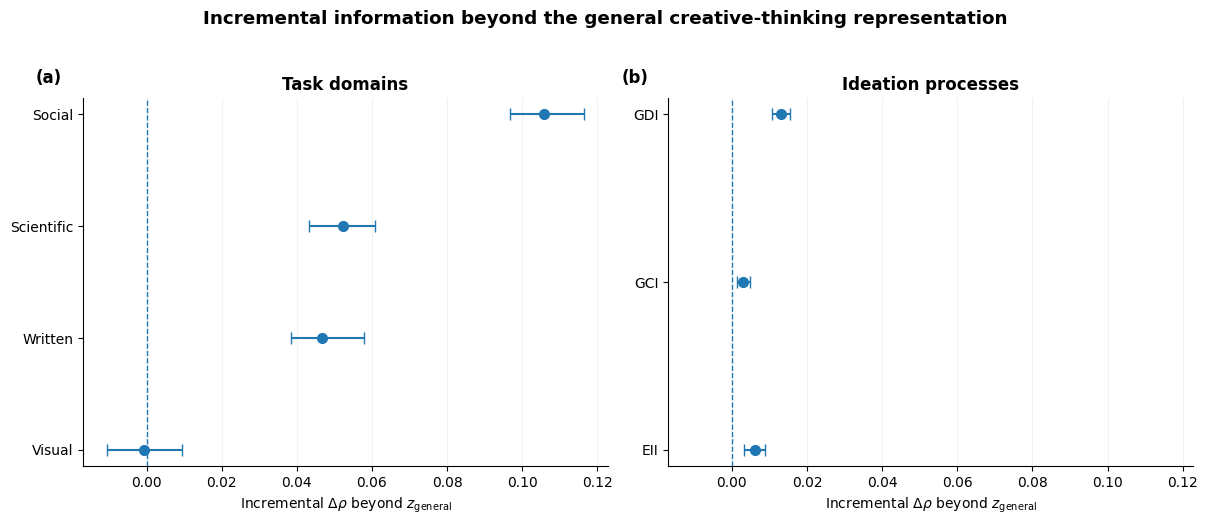

In [ ]:
# Main educational figure:
# Domain-specific vs process-anchored incremental information

import matplotlib.pyplot as plt


domain_ci = pd.read_csv(
    RESULTS_DIR
    / "crest_domain_increment_bootstrap_ci.csv"
)


process_ci = pd.read_csv(
    RESULTS_DIR
    / "crest_process_increment_bootstrap_ci.csv"
)


domain_order = [
    "Social",
    "Scientific",
    "Written",
    "Visual"
]


process_order = [
    "GDI",
    "GCI",
    "EII"
]


domain_plot = (
    domain_ci
    .set_index(
        "domain"
    )
    .loc[
        domain_order
    ]
    .reset_index()
)


process_plot = (
    process_ci
    .set_index(
        "process"
    )
    .loc[
        process_order
    ]
    .reset_index()
)


fig, axes = plt.subplots(
    1,
    2,
    figsize=(
        12.2,
        5.1
    ),
    sharex=True
)


# Panel A - Domains

ax = axes[0]

y_domain = np.arange(
    len(
        domain_plot
    )
)


x = (
    domain_plot[
        "delta_rho_mean"
    ].to_numpy()
)


xerr = np.vstack(
    [
        x
        -
        domain_plot[
            "delta_rho_ci_low"
        ].to_numpy(),

        domain_plot[
            "delta_rho_ci_high"
        ].to_numpy()
        -
        x
    ]
)


ax.errorbar(
    x,
    y_domain,
    xerr=xerr,
    fmt="o",
    markersize=7,
    capsize=4,
    linewidth=1.5
)


ax.axvline(
    0,
    linestyle="--",
    linewidth=1
)


ax.set_yticks(
    y_domain
)

ax.set_yticklabels(
    domain_plot[
        "domain"
    ]
)

ax.invert_yaxis()

ax.set_title(
    "Task domains",
    fontweight="semibold"
)

ax.set_xlabel(
    r"Incremental $\Delta\rho$ beyond "
    r"$z_{\mathrm{general}}$"
)

ax.set_ylabel(
    ""
)

ax.grid(
    axis="x",
    alpha=0.17
)

ax.grid(
    axis="y",
    visible=False
)

ax.spines[
    "top"
].set_visible(
    False
)

ax.spines[
    "right"
].set_visible(
    False
)

ax.text(
    -0.09,
    1.04,
    "(a)",
    transform=ax.transAxes,
    fontsize=12,
    fontweight="semibold"
)


# Panel B - Processes

ax = axes[1]

y_process = np.arange(
    len(
        process_plot
    )
)


x = (
    process_plot[
        "delta_rho_mean"
    ].to_numpy()
)


xerr = np.vstack(
    [
        x
        -
        process_plot[
            "delta_rho_ci_low"
        ].to_numpy(),

        process_plot[
            "delta_rho_ci_high"
        ].to_numpy()
        -
        x
    ]
)


ax.errorbar(
    x,
    y_process,
    xerr=xerr,
    fmt="o",
    markersize=7,
    capsize=4,
    linewidth=1.5
)


ax.axvline(
    0,
    linestyle="--",
    linewidth=1
)


ax.set_yticks(
    y_process
)

ax.set_yticklabels(
    process_plot[
        "process"
    ]
)

ax.invert_yaxis()

ax.set_title(
    "Ideation processes",
    fontweight="semibold"
)

ax.set_xlabel(
    r"Incremental $\Delta\rho$ beyond "
    r"$z_{\mathrm{general}}$"
)

ax.set_ylabel(
    ""
)

ax.grid(
    axis="x",
    alpha=0.17
)

ax.grid(
    axis="y",
    visible=False
)

ax.spines[
    "top"
].set_visible(
    False
)

ax.spines[
    "right"
].set_visible(
    False
)

ax.text(
    -0.09,
    1.04,
    "(b)",
    transform=ax.transAxes,
    fontsize=12,
    fontweight="semibold"
)


fig.suptitle(
    "Incremental information beyond the general "
    "creative-thinking representation",
    fontsize=13.2,
    fontweight="semibold",
    y=1.02
)


fig.tight_layout()


fig.savefig(
    FIG_DIR
    / "crest_domain_vs_process_specificity.pdf",
    bbox_inches="tight"
)


fig.savefig(
    FIG_DIR
    / "crest_domain_vs_process_specificity.png",
    dpi=400,
    bbox_inches="tight"
)


plt.show()

In [ ]:
# Build one out-of-fold latent archive for all students

OOF_DIR = (
    RESULTS_DIR
    / "oof_latents"
)

OOF_DIR.mkdir(
    parents=True,
    exist_ok=True
)


n_students = len(
    primary_meta
)

latent_dim = int(
    CONFIG[
        "latent_dim"
    ]
)


oof_z_general = np.full(
    (
        n_students,
        latent_dim
    ),
    np.nan,
    dtype=np.float32
)


oof_z_context = np.full(
    (
        n_students,
        latent_dim
    ),
    np.nan,
    dtype=np.float32
)


oof_fold = np.full(
    n_students,
    -1,
    dtype=np.int8
)


assignment_count = np.zeros(
    n_students,
    dtype=np.int8
)


for outer_fold in range(
    7
):

    fold_dir = (
        RESULTS_DIR
        / "final_test_outputs"
        / f"fold_{outer_fold}"
    )


    idx = np.load(
        fold_dir
        / "handoff_row_index.npy"
    )


    zg = np.load(
        fold_dir
        / "z_general.npy"
    )


    zc = np.load(
        fold_dir
        / "z_context.npy"
    )


    assert (
        len(idx)
        ==
        len(zg)
        ==
        len(zc)
    )


    assert (
        assignment_count[
            idx
        ]
        == 0
    ).all()


    oof_z_general[
        idx
    ] = zg


    oof_z_context[
        idx
    ] = zc


    oof_fold[
        idx
    ] = outer_fold


    assignment_count[
        idx
    ] += 1


# Integrity

assert (
    assignment_count
    == 1
).all()

assert np.isfinite(
    oof_z_general
).all()

assert np.isfinite(
    oof_z_context
).all()

assert (
    oof_fold
    >= 0
).all()


np.save(
    OOF_DIR
    / "oof_z_general.npy",
    oof_z_general
)

np.save(
    OOF_DIR
    / "oof_z_context.npy",
    oof_z_context
)

np.save(
    OOF_DIR
    / "oof_outer_fold.npy",
    oof_fold
)


oof_index = (
    primary_meta.copy()
)

oof_index[
    "handoff_row_index"
] = np.arange(
    n_students,
    dtype=np.int64
)

oof_index[
    "outer_fold"
] = oof_fold


oof_index.to_pickle(
    OOF_DIR
    / "oof_index.pkl"
)


print(
    "OOF students:",
    n_students
)

print(
    "OOF z_general:",
    oof_z_general.shape
)

print(
    "OOF z_context:",
    oof_z_context.shape
)

print(
    "Every student assigned exactly once: PASS"
)

print(
    "Every representation comes from an unseen-country model: PASS"
)

OOF students: 142564
OOF z_general: (142564, 64)
OOF z_context: (142564, 64)
Every student assigned exactly once: PASS
Every representation comes from an unseen-country model: PASS


In [ ]:
# Audit educational context variables in the OOF cohort

CONTEXT_VARIABLES = [
    "ST004D01T",
    "AGE",
    "REPEAT",
    "HOMEPOS",
    "IMMIG",
    "HOME_TEST_LANG_MATCH",
    "SC001Q01TA",
    "SRESPCUR",
    "SRESPRES"
]


assert set(
    CONTEXT_VARIABLES
).issubset(
    model_context.columns
)


context_audit_rows = []


for variable in CONTEXT_VARIABLES:

    s = (
        model_context[
            variable
        ]
    )


    observed = (
        s.notna()
    )


    row = {

        "variable":
            variable,

        "n_observed":
            int(
                observed.sum()
            ),

        "n_missing":
            int(
                (~observed).sum()
            ),

        "missing_percent":
            float(
                100.0
                *
                (~observed).mean()
            ),

        "n_unique_observed":
            int(
                s[
                    observed
                ].nunique()
            )
    }


    if pd.api.types.is_numeric_dtype(
        s
    ):

        numeric = pd.to_numeric(
            s,
            errors="coerce"
        )

        row.update(
            {
                "mean":
                    float(
                        numeric.mean()
                    ),

                "sd":
                    float(
                        numeric.std()
                    ),

                "min":
                    float(
                        numeric.min()
                    ),

                "max":
                    float(
                        numeric.max()
                    )
            }
        )


    context_audit_rows.append(
        row
    )


context_audit_df = pd.DataFrame(
    context_audit_rows
)


context_audit_df.to_csv(
    RESULTS_DIR
    / "crest_context_variable_audit.csv",
    index=False
)


print(
    context_audit_df.to_string(
        index=False
    )
)


print(
    "\nCategorical value distributions:"
)


for variable in [
    "ST004D01T",
    "REPEAT",
    "IMMIG",
    "HOME_TEST_LANG_MATCH",
    "SC001Q01TA",
    "SRESPCUR",
    "SRESPRES"
]:

    print(
        "\n---",
        variable,
        "---"
    )

    print(
        model_context[
            variable
        ]
        .value_counts(
            dropna=False
        )
        .head(
            20
        )
        .to_string()
    )

            variable  n_observed  n_missing  missing_percent  n_unique_observed      mean       sd     min     max
           ST004D01T      142548         16         0.011223                  2  1.500091 0.500002  1.0000  2.0000
                 AGE      142564          0         0.000000                 16 15.797332 0.290690 15.1700 16.4200
              REPEAT      137737       4827         3.385848                  2  0.103836 0.305048  0.0000  1.0000
             HOMEPOS      139279       3285         2.304228              43983 -0.427355 1.142305 -9.2347  9.2226
               IMMIG      134089       8475         5.944699                  3  1.186346 0.523967  1.0000  3.0000
HOME_TEST_LANG_MATCH      138564       4000         2.805757                  2  0.814180 0.388963  0.0000  1.0000
          SC001Q01TA      135124       7440         5.218709                  6  3.232616 1.227153  1.0000  6.0000
            SRESPCUR      131362      11202         7.857524                  5 

In [ ]:
# Load PISA final and replicate weights
# Robust version: do not assume replicate-weight column prefix.

weights_df = pd.read_pickle(
    HANDOFF_DIR
    / "pisa_weights.pkl"
)


assert len(
    weights_df
) == n_students


assert (
    weights_df[
        "W_FSTUWT"
    ]
    .notna()
    .all()
)


# Identify replicate weights robustly

print(
    "Weight dataframe shape:",
    weights_df.shape
)

print(
    "\nColumns:"
)

print(
    weights_df.columns.tolist()
)


# Known non-replicate columns.
known_nonreplicate = {
    "CNT",
    "CNTRYID",
    "CNTSCHID",
    "CNTSTUID",
    "BOOKID",
    "W_FSTUWT",
    "SENWT"
}


# Everything remaining in this dedicated weights handoff
# should be replicate weights.
replicate_cols = [
    c
    for c in weights_df.columns
    if c not in known_nonreplicate
]


print(
    "\nFinal student weight available:",
    weights_df[
        "W_FSTUWT"
    ]
    .notna()
    .mean()
)

print(
    "Replicate-weight candidates:",
    len(
        replicate_cols
    )
)

print(
    "First 10 replicate columns:",
    replicate_cols[:10]
)


assert len(
    replicate_cols
) == 80, (
    "Expected 80 replicate weights, "
    f"found {len(replicate_cols)}. "
    "Inspect printed column names before continuing."
)


assert (
    weights_df[
        replicate_cols
    ]
    .notna()
    .all()
    .all()
)


print(
    "\nPISA final weight: PASS"
)

print(
    "80 replicate weights: PASS"
)

print(
    "No missing replicate-weight cells: PASS"
)

Weight dataframe shape: (142564, 84)

Columns:
['CNT', 'CNTSTUID', 'W_FSTUWT', 'SENWT', 'W_FSTURWT1', 'W_FSTURWT2', 'W_FSTURWT3', 'W_FSTURWT4', 'W_FSTURWT5', 'W_FSTURWT6', 'W_FSTURWT7', 'W_FSTURWT8', 'W_FSTURWT9', 'W_FSTURWT10', 'W_FSTURWT11', 'W_FSTURWT12', 'W_FSTURWT13', 'W_FSTURWT14', 'W_FSTURWT15', 'W_FSTURWT16', 'W_FSTURWT17', 'W_FSTURWT18', 'W_FSTURWT19', 'W_FSTURWT20', 'W_FSTURWT21', 'W_FSTURWT22', 'W_FSTURWT23', 'W_FSTURWT24', 'W_FSTURWT25', 'W_FSTURWT26', 'W_FSTURWT27', 'W_FSTURWT28', 'W_FSTURWT29', 'W_FSTURWT30', 'W_FSTURWT31', 'W_FSTURWT32', 'W_FSTURWT33', 'W_FSTURWT34', 'W_FSTURWT35', 'W_FSTURWT36', 'W_FSTURWT37', 'W_FSTURWT38', 'W_FSTURWT39', 'W_FSTURWT40', 'W_FSTURWT41', 'W_FSTURWT42', 'W_FSTURWT43', 'W_FSTURWT44', 'W_FSTURWT45', 'W_FSTURWT46', 'W_FSTURWT47', 'W_FSTURWT48', 'W_FSTURWT49', 'W_FSTURWT50', 'W_FSTURWT51', 'W_FSTURWT52', 'W_FSTURWT53', 'W_FSTURWT54', 'W_FSTURWT55', 'W_FSTURWT56', 'W_FSTURWT57', 'W_FSTURWT58', 'W_FSTURWT59', 'W_FSTURWT60', 'W_FSTURWT61', 'W_FST

In [ ]:
# Country-relative, survey-weighted HOMEPOS quartiles

context_oof = pd.DataFrame(
    {
        "handoff_row_index":
            np.arange(
                n_students
            ),

        "CNT":
            primary_meta[
                "CNT"
            ].to_numpy(),

        "outer_fold":
            oof_fold,

        "HOMEPOS":
            pd.to_numeric(
                model_context[
                    "HOMEPOS"
                ],
                errors="coerce"
            ).to_numpy(),

        "ST004D01T":
            model_context[
                "ST004D01T"
            ].to_numpy(),

        "REPEAT":
            model_context[
                "REPEAT"
            ].to_numpy(),

        "IMMIG":
            model_context[
                "IMMIG"
            ].to_numpy(),

        "HOME_TEST_LANG_MATCH":
            model_context[
                "HOME_TEST_LANG_MATCH"
            ].to_numpy(),

        "W_FSTUWT":
            weights_df[
                "W_FSTUWT"
            ].to_numpy()
    }
)


context_oof[
    "HOMEPOS_country_percentile"
] = np.nan


# Survey-weighted percentile within each education system

for country, idx in (
    context_oof
    .groupby(
        "CNT"
    )
    .groups
    .items()
):

    temp = (
        context_oof.loc[
            idx,
            [
                "HOMEPOS",
                "W_FSTUWT"
            ]
        ]
        .copy()
    )


    valid = (
        temp[
            "HOMEPOS"
        ].notna()
        &
        temp[
            "W_FSTUWT"
        ].notna()
        &
        np.isfinite(
            temp[
                "W_FSTUWT"
            ]
        )
        &
        (
            temp[
                "W_FSTUWT"
            ]
            > 0
        )
    )


    temp = temp.loc[
        valid
    ].copy()


    if len(
        temp
    ) == 0:

        continue


    temp = (
        temp
        .sort_values(
            "HOMEPOS",
            kind="mergesort"
        )
    )


    w = (
        temp[
            "W_FSTUWT"
        ]
        .to_numpy(
            dtype=float
        )
    )


    # Midpoint weighted empirical CDF
    weighted_percentile = (
        np.cumsum(
            w
        )
        -
        0.5 * w
    ) / w.sum()


    context_oof.loc[
        temp.index,
        "HOMEPOS_country_percentile"
    ] = weighted_percentile


# Country-relative population quartiles

context_oof[
    "HOMEPOS_quartile"
] = pd.cut(
    context_oof[
        "HOMEPOS_country_percentile"
    ],

    bins=[
        0.0,
        0.25,
        0.50,
        0.75,
        1.0
    ],

    labels=[
        "Q1_low",
        "Q2",
        "Q3",
        "Q4_high"
    ],

    include_lowest=True
)


print(
    context_oof[
        "HOMEPOS_quartile"
    ]
    .value_counts(
        dropna=False
    )
    .sort_index()
)


print(
    "\nObserved HOMEPOS:",
    context_oof[
        "HOMEPOS"
    ].notna().sum()
)

print(
    "Assigned weighted quartile:",
    context_oof[
        "HOMEPOS_quartile"
    ].notna().sum()
)


assert (
    context_oof[
        "HOMEPOS_quartile"
    ].notna().sum()
    ==
    context_oof[
        "HOMEPOS"
    ].notna().sum()
)


context_oof.to_pickle(
    RESULTS_DIR
    / "crest_oof_context_table.pkl"
)


print(
    "\nCountry-relative weighted HOMEPOS quartiles: PASS"
)

HOMEPOS_quartile
Q1_low     33674
Q2         34420
Q3         35088
Q4_high    36097
NaN         3285
Name: count, dtype: int64

Observed HOMEPOS: 139279
Assigned weighted quartile: 139279

Country-relative weighted HOMEPOS quartiles: PASS


In [ ]:
# Assemble OOF creative-signal predictions with context groups

signal_prediction_rows = []


SIGNAL_OUTPUT_DIR = (
    RESULTS_DIR
    / "creative_signal_safeguard"
)


for outer_fold in range(
    7
):

    for direction in [
        "A_to_B",
        "B_to_A"
    ]:

        data = np.load(

            SIGNAL_OUTPUT_DIR
            / (
                f"fold_{outer_fold}_"
                f"{direction}_test_predictions.npz"
            )
        )


        idx = (
            data[
                "handoff_row_index"
            ]
            .astype(
                np.int64
            )
        )


        temp = pd.DataFrame(
            {
                "handoff_row_index":
                    idx,

                "outer_fold":
                    outer_fold,

                "direction":
                    direction,

                "target":
                    data[
                        "target"
                    ],

                "prediction":
                    data[
                        "prediction"
                    ],

                "target_item_count":
                    data[
                        "target_item_count"
                    ]
            }
        )


        temp = temp.merge(

            context_oof[
                [
                    "handoff_row_index",
                    "CNT",
                    "HOMEPOS",
                    "HOMEPOS_country_percentile",
                    "HOMEPOS_quartile",
                    "ST004D01T",
                    "REPEAT",
                    "IMMIG",
                    "HOME_TEST_LANG_MATCH",
                    "W_FSTUWT"
                ]
            ],

            on="handoff_row_index",

            how="left",

            validate="one_to_one"
        )


        signal_prediction_rows.append(
            temp
        )


signal_prediction_df = pd.concat(
    signal_prediction_rows,
    ignore_index=True
)


print(
    "Prediction rows:",
    len(
        signal_prediction_df
    )
)

print(
    "Unique students:",
    signal_prediction_df[
        "handoff_row_index"
    ].nunique()
)

print(
    "Directions:"
)

print(
    signal_prediction_df[
        "direction"
    ].value_counts()
)


signal_prediction_df.to_pickle(
    RESULTS_DIR
    / "crest_oof_signal_predictions_with_context.pkl"
)

Prediction rows: 283170
Unique students: 142331
Directions:
direction
B_to_A    141653
A_to_B    141517
Name: count, dtype: int64


In [ ]:
# Creative-signal robustness across relative home-resource quartiles

homeresource_rows = []


for (
    country,
    quartile,
    direction
), group in (

    signal_prediction_df

    .dropna(
        subset=[
            "HOMEPOS_quartile"
        ]
    )

    .groupby(
        [
            "CNT",
            "HOMEPOS_quartile",
            "direction"
        ],
        observed=True
    )
):


    if len(
        group
    ) < 50:

        continue


    rho = float(
        spearmanr(
            group[
                "target"
            ],
            group[
                "prediction"
            ]
        ).statistic
    )


    mae = float(
        mean_absolute_error(
            group[
                "target"
            ],
            group[
                "prediction"
            ]
        )
    )


    homeresource_rows.append(
        {
            "country":
                country,

            "quartile":
                str(
                    quartile
                ),

            "direction":
                direction,

            "n_students":
                int(
                    len(
                        group
                    )
                ),

            "rho":
                rho,

            "mae":
                mae
        }
    )


homeresource_country_df = pd.DataFrame(
    homeresource_rows
)


homeresource_summary = (

    homeresource_country_df

    .groupby(
        "quartile",
        as_index=False
    )

    .agg(

        n_systems=(
            "country",
            "nunique"
        ),

        rho_mean=(
            "rho",
            "mean"
        ),

        rho_sd=(
            "rho",
            "std"
        ),

        mae_mean=(
            "mae",
            "mean"
        ),

        mae_sd=(
            "mae",
            "std"
        )
    )
)


homeresource_country_df.to_csv(

    RESULTS_DIR
    / "crest_homeresource_fairness_by_system.csv",

    index=False
)


homeresource_summary.to_csv(

    RESULTS_DIR
    / "crest_homeresource_fairness_summary.csv",

    index=False
)


print(
    homeresource_summary.to_string(
        index=False
    )
)


# Extreme-group disparity
# Q4 - Q1 in rank-order transfer

quartile_pivot = (

    homeresource_country_df

    .groupby(
        [
            "country",
            "quartile"
        ],
        as_index=False
    )

    .agg(
        rho=(
            "rho",
            "mean"
        )
    )

    .pivot(
        index="country",
        columns="quartile",
        values="rho"
    )
)


eligible = (
    quartile_pivot[
        [
            "Q1_low",
            "Q4_high"
        ]
    ]
    .dropna()
)


eligible[
    "Q4_minus_Q1_rho"
] = (

    eligible[
        "Q4_high"
    ]

    -

    eligible[
        "Q1_low"
    ]
)


print(
    "\nQ4 - Q1 cross-system rho disparity:"
)

print(
    "Systems:",
    len(
        eligible
    )
)

print(
    "Mean:",
    f"{eligible['Q4_minus_Q1_rho'].mean():+.4f}"
)

print(
    "Median:",
    f"{eligible['Q4_minus_Q1_rho'].median():+.4f}"
)

print(
    "SD:",
    f"{eligible['Q4_minus_Q1_rho'].std(ddof=1):.4f}"
)

quartile  n_systems  rho_mean   rho_sd  mae_mean   mae_sd
  Q1_low         63  0.483305 0.104156  0.181998 0.033722
      Q2         63  0.468657 0.096073  0.179962 0.041241
      Q3         63  0.470849 0.090249  0.178389 0.041303
 Q4_high         63  0.469192 0.097714  0.178387 0.043570

Q4 - Q1 cross-system rho disparity:
Systems: 63
Mean: -0.0141
Median: -0.0056
SD: 0.1137


In [ ]:
# Paired system-bootstrap CIs for home-resource robustness

HOME_BOOT_SEED = 20261009
N_HOME_BOOT = 10000

rng = np.random.default_rng(
    HOME_BOOT_SEED
)


# Average A->B and B->A within each system × quartile first.
home_system = (

    homeresource_country_df

    .groupby(
        [
            "country",
            "quartile"
        ],
        as_index=False
    )

    .agg(
        rho=(
            "rho",
            "mean"
        ),

        mae=(
            "mae",
            "mean"
        )
    )
)


quartile_order = [
    "Q1_low",
    "Q2",
    "Q3",
    "Q4_high"
]


rho_wide = (

    home_system

    .pivot(
        index="country",
        columns="quartile",
        values="rho"
    )

    .loc[
        :,
        quartile_order
    ]
)


mae_wide = (

    home_system

    .pivot(
        index="country",
        columns="quartile",
        values="mae"
    )

    .loc[
        :,
        quartile_order
    ]
)


# All 63 systems should have all four quartiles.
complete = (
    rho_wide.notna().all(axis=1)
    &
    mae_wide.notna().all(axis=1)
)


rho_wide = rho_wide.loc[
    complete
]

mae_wide = mae_wide.loc[
    complete
]


assert len(
    rho_wide
) == 63


rho_array = rho_wide.to_numpy(
    dtype=float
)

mae_array = mae_wide.to_numpy(
    dtype=float
)


boot_rho_means = []
boot_mae_means = []

boot_q4_q1_rho = []
boot_q4_q1_mae = []


for _ in range(
    N_HOME_BOOT
):

    idx = rng.integers(
        0,
        len(
            rho_array
        ),
        size=len(
            rho_array
        )
    )


    rho_sample = (
        rho_array[
            idx
        ]
    )

    mae_sample = (
        mae_array[
            idx
        ]
    )


    boot_rho_means.append(
        rho_sample.mean(
            axis=0
        )
    )

    boot_mae_means.append(
        mae_sample.mean(
            axis=0
        )
    )


    boot_q4_q1_rho.append(
        (
            rho_sample[
                :,
                3
            ]
            -
            rho_sample[
                :,
                0
            ]
        ).mean()
    )


    boot_q4_q1_mae.append(
        (
            mae_sample[
                :,
                3
            ]
            -
            mae_sample[
                :,
                0
            ]
        ).mean()
    )


boot_rho_means = np.asarray(
    boot_rho_means
)

boot_mae_means = np.asarray(
    boot_mae_means
)

boot_q4_q1_rho = np.asarray(
    boot_q4_q1_rho
)

boot_q4_q1_mae = np.asarray(
    boot_q4_q1_mae
)


quartile_ci_rows = []


for j, quartile in enumerate(
    quartile_order
):

    quartile_ci_rows.append(
        {
            "quartile":
                quartile,

            "rho_mean":
                float(
                    rho_array[
                        :,
                        j
                    ].mean()
                ),

            "rho_ci_low":
                float(
                    np.quantile(
                        boot_rho_means[
                            :,
                            j
                        ],
                        0.025
                    )
                ),

            "rho_ci_high":
                float(
                    np.quantile(
                        boot_rho_means[
                            :,
                            j
                        ],
                        0.975
                    )
                ),

            "mae_mean":
                float(
                    mae_array[
                        :,
                        j
                    ].mean()
                ),

            "mae_ci_low":
                float(
                    np.quantile(
                        boot_mae_means[
                            :,
                            j
                        ],
                        0.025
                    )
                ),

            "mae_ci_high":
                float(
                    np.quantile(
                        boot_mae_means[
                            :,
                            j
                        ],
                        0.975
                    )
                )
        }
    )


home_quartile_ci = pd.DataFrame(
    quartile_ci_rows
)


gap_summary = pd.DataFrame(
    {
        "contrast": [
            "Q4_high_minus_Q1_low_rho",
            "Q4_high_minus_Q1_low_mae"
        ],

        "estimate": [
            float(
                (
                    rho_array[:, 3]
                    -
                    rho_array[:, 0]
                ).mean()
            ),

            float(
                (
                    mae_array[:, 3]
                    -
                    mae_array[:, 0]
                ).mean()
            )
        ],

        "ci_low": [
            float(
                np.quantile(
                    boot_q4_q1_rho,
                    0.025
                )
            ),

            float(
                np.quantile(
                    boot_q4_q1_mae,
                    0.025
                )
            )
        ],

        "ci_high": [
            float(
                np.quantile(
                    boot_q4_q1_rho,
                    0.975
                )
            ),

            float(
                np.quantile(
                    boot_q4_q1_mae,
                    0.975
                )
            )
        ]
    }
)


home_quartile_ci.to_csv(
    RESULTS_DIR
    / "crest_homeresource_quartile_bootstrap_ci.csv",
    index=False
)


gap_summary.to_csv(
    RESULTS_DIR
    / "crest_homeresource_extreme_gap_bootstrap_ci.csv",
    index=False
)


print(
    "QUARTILE ESTIMATES"
)

print(
    home_quartile_ci.to_string(
        index=False
    )
)


print(
    "\nEXTREME-GROUP CONTRAST"
)

print(
    gap_summary.to_string(
        index=False
    )
)

QUARTILE ESTIMATES
quartile  rho_mean  rho_ci_low  rho_ci_high  mae_mean  mae_ci_low  mae_ci_high
  Q1_low  0.483305    0.457769     0.507103  0.181998    0.174907     0.190506
      Q2  0.468657    0.444535     0.491560  0.179962    0.171388     0.190972
      Q3  0.470849    0.448801     0.491973  0.178389    0.169919     0.189616
 Q4_high  0.469192    0.445174     0.493214  0.178387    0.169640     0.190472

EXTREME-GROUP CONTRAST
                contrast  estimate    ci_low  ci_high
Q4_high_minus_Q1_low_rho -0.014113 -0.042521 0.014492
Q4_high_minus_Q1_low_mae -0.003611 -0.008059 0.001648


In [ ]:
# Context-group robustness:
# grade repetition and immigrant background

fairness_df = (
    signal_prediction_df.copy()
)


fairness_df[
    "REPEAT_group"
] = fairness_df[
    "REPEAT"
].map(
    {
        0.0:
            "Never repeated",

        1.0:
            "Repeated grade"
    }
)


fairness_df[
    "IMMIG_group"
] = fairness_df[
    "IMMIG"
].map(
    {
        1.0:
            "Native",

        2.0:
            "Immigrant background",

        3.0:
            "Immigrant background"
    }
)


def context_group_metrics(
    df,
    group_variable,
    minimum_n=50
):

    rows = []


    temp = df.dropna(
        subset=[
            group_variable
        ]
    )


    for (
        country,
        group_name,
        direction
    ), group in temp.groupby(
        [
            "CNT",
            group_variable,
            "direction"
        ],
        observed=True
    ):

        if len(
            group
        ) < minimum_n:

            continue


        rho = float(
            spearmanr(
                group[
                    "target"
                ],
                group[
                    "prediction"
                ]
            ).statistic
        )


        mae = float(
            mean_absolute_error(
                group[
                    "target"
                ],
                group[
                    "prediction"
                ]
            )
        )


        rows.append(
            {
                "country":
                    country,

                "group":
                    group_name,

                "direction":
                    direction,

                "n_students":
                    int(
                        len(
                            group
                        )
                    ),

                "rho":
                    rho,

                "mae":
                    mae
            }
        )


    country_df = pd.DataFrame(
        rows
    )


    # First average the two directions within
    # each system × contextual group.
    system_df = (

        country_df

        .groupby(
            [
                "country",
                "group"
            ],
            as_index=False
        )

        .agg(
            n_directions=(
                "direction",
                "nunique"
            ),

            rho=(
                "rho",
                "mean"
            ),

            mae=(
                "mae",
                "mean"
            )
        )
    )


    # Require both A->B and B->A.
    system_df = (
        system_df[
            system_df[
                "n_directions"
            ]
            == 2
        ]
        .copy()
    )


    summary = (

        system_df

        .groupby(
            "group",
            as_index=False
        )

        .agg(
            n_systems=(
                "country",
                "nunique"
            ),

            rho_mean=(
                "rho",
                "mean"
            ),

            rho_sd=(
                "rho",
                "std"
            ),

            mae_mean=(
                "mae",
                "mean"
            ),

            mae_sd=(
                "mae",
                "std"
            )
        )
    )


    return (
        country_df,
        system_df,
        summary
    )


(
    repeat_country,
    repeat_system,
    repeat_summary
) = context_group_metrics(
    fairness_df,
    "REPEAT_group"
)


(
    immigr_country,
    immigr_system,
    immigr_summary
) = context_group_metrics(
    fairness_df,
    "IMMIG_group"
)


print(
    "GRADE REPETITION"
)

print(
    "=" * 60
)

print(
    repeat_summary.to_string(
        index=False
    )
)


print(
    "\nIMMIGRANT BACKGROUND"
)

print(
    "=" * 60
)

print(
    immigr_summary.to_string(
        index=False
    )
)


repeat_system.to_csv(
    RESULTS_DIR
    / "crest_repeat_robustness_by_system.csv",
    index=False
)


immigr_system.to_csv(
    RESULTS_DIR
    / "crest_immigration_robustness_by_system.csv",
    index=False
)

GRADE REPETITION
         group  n_systems  rho_mean   rho_sd  mae_mean   mae_sd
Never repeated         63  0.493366 0.087764  0.178658 0.039124
Repeated grade         50  0.472482 0.108062  0.187133 0.022166

IMMIGRANT BACKGROUND
               group  n_systems  rho_mean   rho_sd  mae_mean   mae_sd
Immigrant background         37  0.508423 0.090171  0.174610 0.028738
              Native         63  0.504739 0.081434  0.178566 0.036518


In [ ]:
# Paired system-bootstrap contrasts for contextual robustness

CONTEXT_BOOT_SEED = 20261010
N_CONTEXT_BOOT = 10000

rng = np.random.default_rng(
    CONTEXT_BOOT_SEED
)


def paired_context_bootstrap(
    system_df,
    group_a,
    group_b,
    contrast_name,
    n_boot=10000
):

    # Create paired system-level table

    rho_wide = (
        system_df
        .pivot(
            index="country",
            columns="group",
            values="rho"
        )
    )

    mae_wide = (
        system_df
        .pivot(
            index="country",
            columns="group",
            values="mae"
        )
    )


    eligible = (
        rho_wide[
            [
                group_a,
                group_b
            ]
        ]
        .dropna()
        .index
        .intersection(
            mae_wide[
                [
                    group_a,
                    group_b
                ]
            ]
            .dropna()
            .index
        )
    )


    rho_pair = (
        rho_wide.loc[
            eligible,
            [
                group_a,
                group_b
            ]
        ]
        .to_numpy(
            dtype=float
        )
    )


    mae_pair = (
        mae_wide.loc[
            eligible,
            [
                group_a,
                group_b
            ]
        ]
        .to_numpy(
            dtype=float
        )
    )


    # Defined as B - A
    rho_diff = (
        rho_pair[
            :,
            1
        ]
        -
        rho_pair[
            :,
            0
        ]
    )


    mae_diff = (
        mae_pair[
            :,
            1
        ]
        -
        mae_pair[
            :,
            0
        ]
    )


    rho_boot = []
    mae_boot = []


    for _ in range(
        n_boot
    ):

        idx = rng.integers(
            0,
            len(
                eligible
            ),
            size=len(
                eligible
            )
        )


        rho_boot.append(
            rho_diff[
                idx
            ].mean()
        )


        mae_boot.append(
            mae_diff[
                idx
            ].mean()
        )


    rho_boot = np.asarray(
        rho_boot
    )

    mae_boot = np.asarray(
        mae_boot
    )


    result = pd.DataFrame(
        [
            {
                "contrast":
                    f"{contrast_name}_rho",

                "group_A":
                    group_a,

                "group_B":
                    group_b,

                "n_paired_systems":
                    len(
                        eligible
                    ),

                "estimate_B_minus_A":
                    float(
                        rho_diff.mean()
                    ),

                "ci_low":
                    float(
                        np.quantile(
                            rho_boot,
                            0.025
                        )
                    ),

                "ci_high":
                    float(
                        np.quantile(
                            rho_boot,
                            0.975
                        )
                    )
            },

            {
                "contrast":
                    f"{contrast_name}_mae",

                "group_A":
                    group_a,

                "group_B":
                    group_b,

                "n_paired_systems":
                    len(
                        eligible
                    ),

                "estimate_B_minus_A":
                    float(
                        mae_diff.mean()
                    ),

                "ci_low":
                    float(
                        np.quantile(
                            mae_boot,
                            0.025
                        )
                    ),

                "ci_high":
                    float(
                        np.quantile(
                            mae_boot,
                            0.975
                        )
                    )
            }
        ]
    )


    return (
        result,
        eligible
    )


# Grade repetition
# B - A = repeated - never repeated

repeat_bootstrap, repeat_systems = (
    paired_context_bootstrap(

        repeat_system,

        group_a="Never repeated",

        group_b="Repeated grade",

        contrast_name=(
            "repeated_minus_never_repeated"
        ),

        n_boot=N_CONTEXT_BOOT
    )
)


# Immigration
# B - A = immigrant-background - native

immigr_bootstrap, immigr_systems = (
    paired_context_bootstrap(

        immigr_system,

        group_a="Native",

        group_b="Immigrant background",

        contrast_name=(
            "immigrant_background_minus_native"
        ),

        n_boot=N_CONTEXT_BOOT
    )
)


context_bootstrap_df = pd.concat(
    [
        repeat_bootstrap,
        immigr_bootstrap
    ],
    ignore_index=True
)


context_bootstrap_df.to_csv(

    RESULTS_DIR
    / "crest_context_group_bootstrap_contrasts.csv",

    index=False
)


print(
    context_bootstrap_df.to_string(
        index=False
    )
)


print(
    "\nPaired systems — grade repetition:",
    len(
        repeat_systems
    )
)

print(
    "Paired systems — immigrant background:",
    len(
        immigr_systems
    )
)

                             contrast        group_A              group_B  n_paired_systems  estimate_B_minus_A    ci_low  ci_high
    repeated_minus_never_repeated_rho Never repeated       Repeated grade                50           -0.023082 -0.050476 0.002294
    repeated_minus_never_repeated_mae Never repeated       Repeated grade                50            0.010511  0.005213 0.015376
immigrant_background_minus_native_rho         Native Immigrant background                37            0.006611 -0.017906 0.028791
immigrant_background_minus_native_mae         Native Immigrant background                37            0.003405  0.000061 0.007375

Paired systems — grade repetition: 50
Paired systems — immigrant background: 37


In [ ]:
# Gender and home/test-language-match robustness

fairness_df = (
    signal_prediction_df.copy()
)


# Gender
# ST004D01T: 1 = Female, 2 = Male

fairness_df[
    "GENDER_group"
] = fairness_df[
    "ST004D01T"
].map(
    {
        1.0:
            "Female",

        2.0:
            "Male"
    }
)


# Project-derived language-match indicator
# 1 = home language matches assessment/test language
# 0 = another language

fairness_df[
    "LANGUAGE_group"
] = fairness_df[
    "HOME_TEST_LANG_MATCH"
].map(
    {
        1.0:
            "Home/test language match",

        0.0:
            "Home/test language mismatch"
    }
)


(
    gender_country,
    gender_system,
    gender_summary
) = context_group_metrics(
    fairness_df,
    "GENDER_group"
)


(
    language_country,
    language_system,
    language_summary
) = context_group_metrics(
    fairness_df,
    "LANGUAGE_group"
)


print(
    "GENDER"
)

print(
    "=" * 60
)

print(
    gender_summary.to_string(
        index=False
    )
)


print(
    "\nHOME / TEST LANGUAGE"
)

print(
    "=" * 60
)

print(
    language_summary.to_string(
        index=False
    )
)


gender_system.to_csv(
    RESULTS_DIR
    / "crest_gender_robustness_by_system.csv",
    index=False
)


language_system.to_csv(
    RESULTS_DIR
    / "crest_language_robustness_by_system.csv",
    index=False
)

GENDER
 group  n_systems  rho_mean   rho_sd  mae_mean   mae_sd
Female         63  0.490291 0.087286  0.179994 0.042216
  Male         63  0.521152 0.090689  0.179389 0.033971

HOME / TEST LANGUAGE
                      group  n_systems  rho_mean   rho_sd  mae_mean   mae_sd
   Home/test language match         63  0.500973 0.086740  0.179375 0.041331
Home/test language mismatch         53  0.524045 0.095959  0.181944 0.028081


In [ ]:
# Paired system-bootstrap for gender and language match

(
    gender_bootstrap,
    gender_systems
) = paired_context_bootstrap(

    gender_system,

    group_a="Female",

    group_b="Male",

    contrast_name=(
        "male_minus_female"
    ),

    n_boot=10000
)


(
    language_bootstrap,
    language_systems
) = paired_context_bootstrap(

    language_system,

    group_a=(
        "Home/test language match"
    ),

    group_b=(
        "Home/test language mismatch"
    ),

    contrast_name=(
        "language_mismatch_minus_match"
    ),

    n_boot=10000
)


gender_language_bootstrap = (
    pd.concat(
        [
            gender_bootstrap,
            language_bootstrap
        ],
        ignore_index=True
    )
)


gender_language_bootstrap.to_csv(

    RESULTS_DIR
    / "crest_gender_language_bootstrap_contrasts.csv",

    index=False
)


print(
    gender_language_bootstrap.to_string(
        index=False
    )
)


print(
    "\nPaired systems — gender:",
    len(
        gender_systems
    )
)


print(
    "Paired systems — language:",
    len(
        language_systems
    )
)

                         contrast                  group_A                     group_B  n_paired_systems  estimate_B_minus_A    ci_low  ci_high
            male_minus_female_rho                   Female                        Male                63            0.030861  0.019245 0.042747
            male_minus_female_mae                   Female                        Male                63           -0.000605 -0.003363 0.001673
language_mismatch_minus_match_rho Home/test language match Home/test language mismatch                53            0.025546  0.005121 0.046510
language_mismatch_minus_match_mae Home/test language match Home/test language mismatch                53            0.001473 -0.007179 0.008182

Paired systems — gender: 63
Paired systems — language: 53


In [ ]:
# Consolidated contextual robustness summary

home_gap = pd.read_csv(
    RESULTS_DIR
    / "crest_homeresource_extreme_gap_bootstrap_ci.csv"
)

repeat_immig = pd.read_csv(
    RESULTS_DIR
    / "crest_context_group_bootstrap_contrasts.csv"
)

gender_language = pd.read_csv(
    RESULTS_DIR
    / "crest_gender_language_bootstrap_contrasts.csv"
)


rows = []


# Home resources
# Q4 high - Q1 low

for metric in ["rho", "mae"]:

    row = home_gap[
        home_gap[
            "contrast"
        ]
        == f"Q4_high_minus_Q1_low_{metric}"
    ].iloc[0]

    rows.append(
        {
            "context":
                "Home resources",

            "contrast":
                "Q4 high − Q1 low",

            "metric":
                metric,

            "estimate":
                float(
                    row[
                        "estimate"
                    ]
                ),

            "ci_low":
                float(
                    row[
                        "ci_low"
                    ]
                ),

            "ci_high":
                float(
                    row[
                        "ci_high"
                    ]
                ),

            "n_paired_systems":
                63
        }
    )


# Other contrasts

source_tables = [
    repeat_immig,
    gender_language
]


label_map = {

    "repeated_minus_never_repeated":
        (
            "Grade repetition",
            "Repeated − Never repeated"
        ),

    "immigrant_background_minus_native":
        (
            "Immigrant background",
            "Immigrant background − Native"
        ),

    "male_minus_female":
        (
            "Gender",
            "Male − Female"
        ),

    "language_mismatch_minus_match":
        (
            "Home/test language",
            "Mismatch − Match"
        )
}


for table in source_tables:

    for _, row in table.iterrows():

        contrast = str(
            row[
                "contrast"
            ]
        )

        metric = (
            "rho"
            if contrast.endswith(
                "_rho"
            )
            else "mae"
        )

        base_name = (
            contrast[
                :-4
            ]
            if metric == "rho"
            else contrast[
                :-4
            ]
        )

        context_name, display_contrast = (
            label_map[
                base_name
            ]
        )


        rows.append(
            {
                "context":
                    context_name,

                "contrast":
                    display_contrast,

                "metric":
                    metric,

                "estimate":
                    float(
                        row[
                            "estimate_B_minus_A"
                        ]
                    ),

                "ci_low":
                    float(
                        row[
                            "ci_low"
                        ]
                    ),

                "ci_high":
                    float(
                        row[
                            "ci_high"
                        ]
                    ),

                "n_paired_systems":
                    int(
                        row[
                            "n_paired_systems"
                        ]
                    )
            }
        )


context_robustness_summary = pd.DataFrame(
    rows
)


context_robustness_summary.to_csv(
    RESULTS_DIR
    / "crest_context_robustness_consolidated.csv",
    index=False
)


print(
    context_robustness_summary.to_string(
        index=False
    )
)

             context                      contrast metric  estimate    ci_low  ci_high  n_paired_systems
      Home resources              Q4 high − Q1 low    rho -0.014113 -0.042521 0.014492                63
      Home resources              Q4 high − Q1 low    mae -0.003611 -0.008059 0.001648                63
    Grade repetition     Repeated − Never repeated    rho -0.023082 -0.050476 0.002294                50
    Grade repetition     Repeated − Never repeated    mae  0.010511  0.005213 0.015376                50
Immigrant background Immigrant background − Native    rho  0.006611 -0.017906 0.028791                37
Immigrant background Immigrant background − Native    mae  0.003405  0.000061 0.007375                37
              Gender                 Male − Female    rho  0.030861  0.019245 0.042747                63
              Gender                 Male − Female    mae -0.000605 -0.003363 0.001673                63
  Home/test language              Mismatch − Match    r

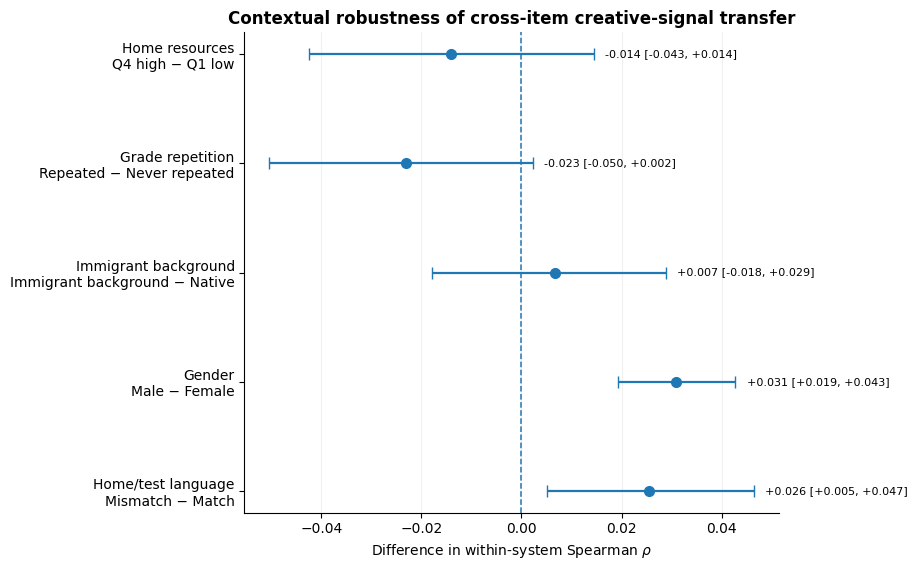

In [ ]:
# Contextual robustness forest plot

import matplotlib.pyplot as plt


rho_plot = (
    context_robustness_summary[
        context_robustness_summary[
            "metric"
        ]
        == "rho"
    ]
    .copy()
)


order = [
    "Home resources",
    "Grade repetition",
    "Immigrant background",
    "Gender",
    "Home/test language"
]


rho_plot = (
    rho_plot
    .set_index(
        "context"
    )
    .loc[
        order
    ]
    .reset_index()
)


y = np.arange(
    len(
        rho_plot
    )
)


estimate = (
    rho_plot[
        "estimate"
    ].to_numpy()
)


lower = (
    estimate
    -
    rho_plot[
        "ci_low"
    ].to_numpy()
)


upper = (
    rho_plot[
        "ci_high"
    ].to_numpy()
    -
    estimate
)


fig, ax = plt.subplots(
    figsize=(
        9.2,
        5.8
    )
)


ax.errorbar(
    estimate,
    y,
    xerr=np.vstack(
        [
            lower,
            upper
        ]
    ),
    fmt="o",
    markersize=7,
    capsize=4,
    linewidth=1.6
)


ax.axvline(
    0,
    linestyle="--",
    linewidth=1.1
)


ax.set_yticks(
    y
)


ax.set_yticklabels(
    [
        (
            f"{row['context']}\n"
            f"{row['contrast']}"
        )
        for _, row
        in rho_plot.iterrows()
    ]
)


ax.invert_yaxis()


ax.set_xlabel(
    r"Difference in within-system Spearman $\rho$"
)


ax.set_ylabel(
    ""
)


ax.set_title(
    "Contextual robustness of cross-item creative-signal transfer",
    fontweight="semibold"
)


ax.grid(
    axis="x",
    alpha=0.18
)

ax.grid(
    axis="y",
    visible=False
)


ax.spines[
    "top"
].set_visible(
    False
)

ax.spines[
    "right"
].set_visible(
    False
)


# Numeric annotations
for i, row in rho_plot.iterrows():

    ax.annotate(
        (
            f"{row['estimate']:+.3f} "
            f"[{row['ci_low']:+.3f}, "
            f"{row['ci_high']:+.3f}]"
        ),
        (
            row[
                "ci_high"
            ],
            i
        ),
        xytext=(
            8,
            0
        ),
        textcoords="offset points",
        va="center",
        fontsize=8
    )


fig.tight_layout()


fig.savefig(
    FIG_DIR
    / "crest_contextual_robustness_forest.pdf",
    bbox_inches="tight"
)


fig.savefig(
    FIG_DIR
    / "crest_contextual_robustness_forest.png",
    dpi=400,
    bbox_inches="tight"
)


plt.show()